# Land use prediction

In [1]:
import pandas as pd
blocks_gdf = pd.read_pickle('./../../data/saint_petersburg/blocks.pickle')

In [2]:
from blocksnet.analysis.land_use.prediction import SpatialClassifier

classifier = SpatialClassifier.default()

/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Hi

/home/vasilstar/masterplanning/blocksnet/analysis/land_use/prediction/artifacts


/usr/lib/python3.10/pickle.py:1718: UserWarning: [22:51:49] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/vasilstar/masterplanning/.ve

In [3]:
result = classifier.run(blocks_gdf)

/home/vasilstar/masterplanning/blocksnet/analysis/land_use/prediction/preprocessing.py:249: RuntimeWarning: divide by zero encountered in divide
  rectangularity = np.where(mbr_area>0, area/mbr_area, 0)
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [4]:
result

,geometry,category,pred_name,prob_urban,prob_non_urban,prob_industrial
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",LandUseCategory.NON_URBAN,non_urban,0.377408,0.395913,0.226679
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",LandUseCategory.URBAN,urban,0.525952,0.190505,0.283544
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",LandUseCategory.URBAN,urban,0.836375,0.101283,0.062341
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",LandUseCategory.URBAN,urban,0.701378,0.166370,0.132252
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",LandUseCategory.URBAN,urban,0.793235,0.117476,0.089289
...,...,...,...,...,...,...
9528,"POLYGON ((346635.461 6647492.048, 346473.426 6...",LandUseCategory.URBAN,urban,0.575336,0.400816,0.023849
9529,"POLYGON ((346361.221 6647603.446, 346328.072 6...",LandUseCategory.URBAN,urban,0.916707,0.052323,0.030970
9530,"POLYGON ((344109.285 6649134.367, 344000.209 6...",LandUseCategory.URBAN,urban,0.859929,0.087694,0.052377
9531,"POLYGON ((346323.488 6649497.386, 346199.573 6...",LandUseCategory.URBAN,urban,0.845145,0.103715,0.051140


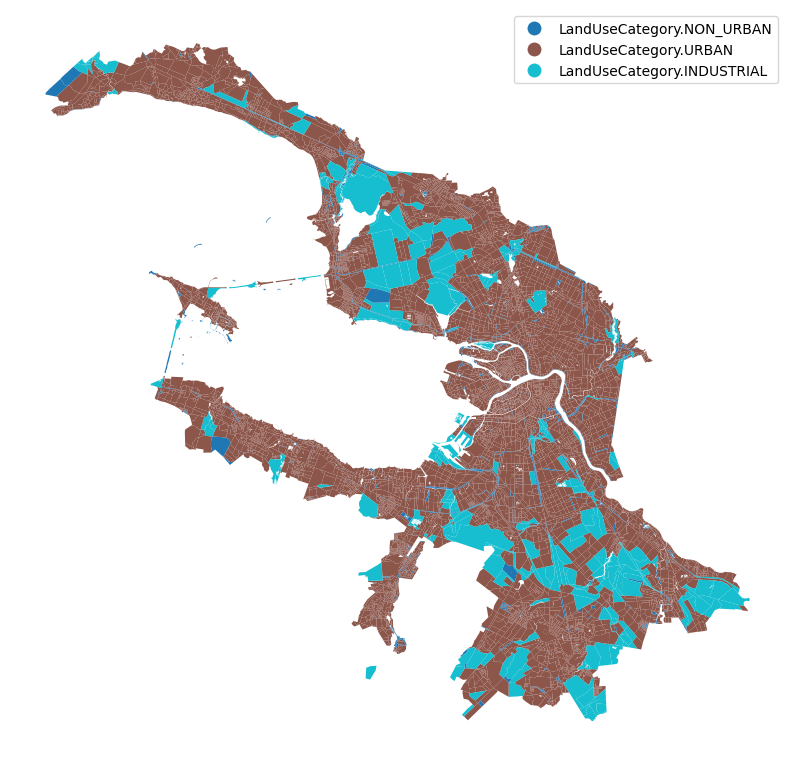

In [8]:
result.plot('category', legend=True, figsize=(10,10)).set_axis_off()

# Land Use Train Mode

In [4]:
import os
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from blocksnet.analysis.land_use.prediction import SpatialClassifier
from blocksnet.machine_learning.strategy.sklearn.ensemble.voting.classification_strategy import SKLearnVotingClassificationStrategy

In [5]:
import pandas as pd
blocks_gdf = pd.read_pickle('./../../data/saint_petersburg/blocks.pickle')

In [7]:
# 1. Инициализация и обучение
BASE_PARAMS = {"random_state": 42, "n_jobs": -1}
CPU = max(1, min(8, os.cpu_count() or 1))
MODEL_PARAMS = {
    "rf": {
        "n_estimators": 120,          # было 200
        "max_depth": 7,
        "class_weight": "balanced",
        "max_samples": 0.25,          # 🔴 бэггинг на подвыборке
        "min_samples_leaf": 10,       # стабилизация и меньше узлов
        **BASE_PARAMS
    },
    "xgb": {
        "n_estimators": 150,          # меньше
        "max_depth": 7,
        "learning_rate": 0.05,
        "subsample": 0.8,             # стахастичность
        "colsample_bytree": 0.8,
        "tree_method": "hist",        # память/скорость
        "n_jobs": CPU                 # XGB игнорирует BASE_PARAMS если его стерли
    },
    "lgb": {
        "n_estimators": 200,
        "max_depth": 7,
        "learning_rate": 0.05,
        "class_weight": "balanced",
        "num_threads": CPU            # у LGB параметр другое имя
    },
    "hgb": {
        "max_iter": 200,
        "max_depth": 7,
        "learning_rate": 0.05,
        "random_state": 42
    }
}
estimators = [
    ("rf",  RandomForestClassifier(**MODEL_PARAMS["rf"])),
    ("xgb", XGBClassifier(**MODEL_PARAMS["xgb"])),
    ("lgb", LGBMClassifier(**MODEL_PARAMS["lgb"])),
    ("hgb", HistGradientBoostingClassifier(**MODEL_PARAMS["hgb"])),
]

strategy = SKLearnVotingClassificationStrategy(estimators, {"voting": "soft", "n_jobs": -1})
classifier = SpatialClassifier(strategy, 1000, 5)
score = classifier.train(blocks_gdf[~blocks_gdf.land_use.isna()])

/home/vasilstar/masterplanning/blocksnet/analysis/land_use/prediction/preprocessing.py:249: RuntimeWarning: divide by zero encountered in divide
  rectangularity = np.where(mbr_area>0, area/mbr_area, 0)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 7412, number of used features: 30
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
